
# ESG Text Classification — EDA Notebook

This notebook contains all the EDA code in one place:

- Dataset overview
- Multi-label class distribution
- Label cardinality and co-occurrence
- Outlier analysis on text-derived numeric features
- Word clouds per class
- Export of summary tables

Update the `csv_path` if your file is in a different location.


In [1]:

import os, re, zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

try:
    from wordcloud import WordCloud, STOPWORDS
    WORDCLOUD_AVAILABLE = True
except Exception as e:
    WORDCLOUD_AVAILABLE = False
    WORDCLOUD_IMPORT_ERROR = str(e)

plt.rcParams['figure.figsize'] = (8, 5)


In [2]:

# Load data
csv_path = '/mnt/data/train (1).csv'  # change this if needed
df = pd.read_csv(csv_path)
df.columns = [str(c) for c in df.columns]

print('Shape:', df.shape)
print('Columns:', list(df.columns))
display(df.head())


Shape: (26750, 6)
Columns: ['id', 'text', 'E', 'S', 'G', 'non_ESG']


,id,text,E,S,G,non_ESG
0,0,In addition to shares held by the Family Trust...,0,1,0,0
1,1,The topics in this report were identified thro...,0,0,0,1
2,2,"For this reason, the Energy Management Dashboa...",0,0,0,1
3,3,"Environment, social and governance | ENVIRONME...",0,0,0,1
4,4,Subject to the appointment of the nominated ca...,0,1,0,0


In [3]:

# Detect text and label columns
TEXT_COL = 'text' if 'text' in df.columns else None

binary_cols = []
for c in df.columns:
    if c in ['id', TEXT_COL]:
        continue
    if pd.api.types.is_numeric_dtype(df[c]):
        vals = set(pd.Series(df[c].dropna().unique()).astype(int).tolist()) if df[c].dropna().nunique() <= 10 else set()
        if vals.issubset({0, 1}) and len(vals) >= 1:
            binary_cols.append(c)

print('Text column:', TEXT_COL)
print('Detected binary label columns:', binary_cols)


Text column: text
Detected binary label columns: ['E', 'S', 'G', 'non_ESG']


In [4]:

# Dataset overview
n_rows, n_cols = df.shape
overview = {
    'rows': n_rows,
    'columns': n_cols,
    'missing_cells': int(df.isna().sum().sum()),
    'missing_pct': float(df.isna().sum().sum() / (n_rows*n_cols) * 100),
}
print(overview)

missing_by_col = df.isna().sum().sort_values(ascending=False)
display(pd.DataFrame({
    'column': missing_by_col.index,
    'missing_count': missing_by_col.values,
    'dtype': [str(df[c].dtype) for c in missing_by_col.index]
}))


{'rows': 26750, 'columns': 6, 'missing_cells': 52, 'missing_pct': 0.032398753894081}


,column,missing_count,dtype
0,text,52,object
1,id,0,int64
2,E,0,int64
3,S,0,int64
4,G,0,int64
5,non_ESG,0,int64


,count,pct_of_rows
non_ESG,11389,42.58
S,9910,37.05
G,8857,33.11
E,1180,4.41


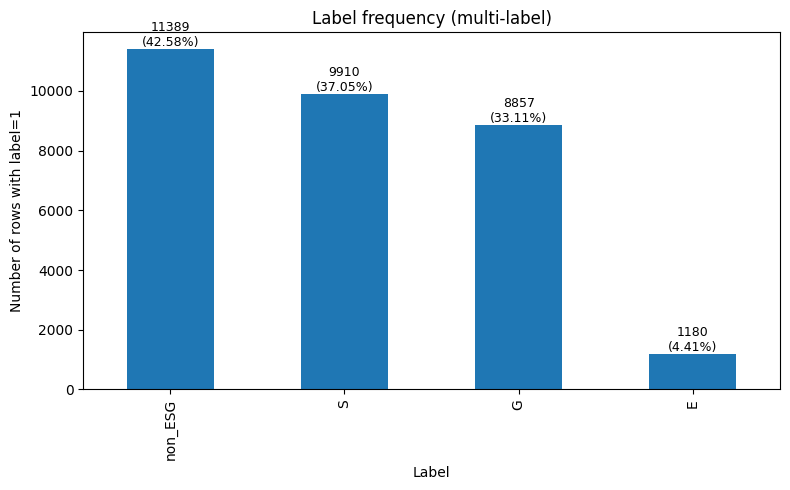

In [5]:

# Label distribution
label_counts = df[binary_cols].sum().sort_values(ascending=False).astype(int)
label_pct = (label_counts / len(df) * 100).round(2)
label_dist_df = pd.DataFrame({'count': label_counts, 'pct_of_rows': label_pct})
display(label_dist_df)

plt.figure(figsize=(8,5))
label_counts.plot(kind='bar')
plt.title('Label frequency (multi-label)')
plt.xlabel('Label')
plt.ylabel('Number of rows with label=1')
for i, v in enumerate(label_counts.values):
    plt.text(i, v, f'{v}\n({label_pct.iloc[i]}%)', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()


,count
0,51
1,22517
2,3927
3,55
4,200


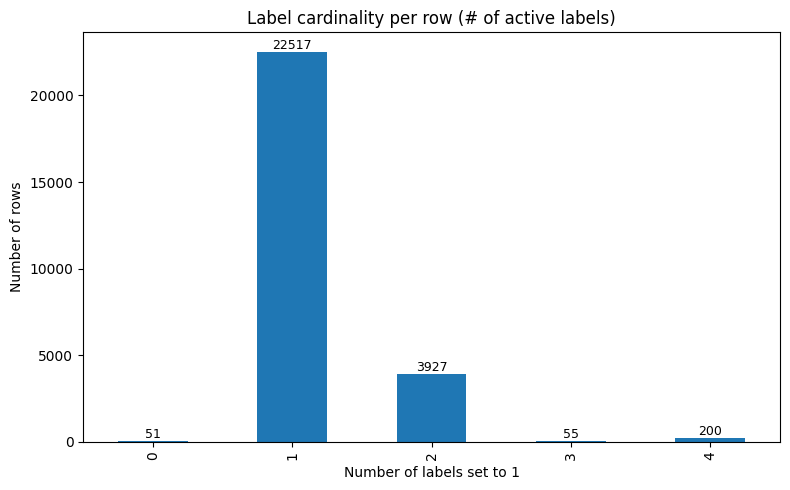

In [6]:

# Label cardinality
label_card = df[binary_cols].sum(axis=1).astype(int)
card_counts = label_card.value_counts().sort_index()
display(card_counts.to_frame('count'))

plt.figure(figsize=(8,5))
card_counts.plot(kind='bar')
plt.title('Label cardinality per row (# of active labels)')
plt.xlabel('Number of labels set to 1')
plt.ylabel('Number of rows')
for i, (k, v) in enumerate(card_counts.items()):
    plt.text(i, v, f'{v}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()


,E,S,G,non_ESG
E,1180.0,517.0,517.0,200.0
S,517.0,9910.0,3658.0,200.0
G,517.0,3658.0,8857.0,200.0
non_ESG,200.0,200.0,200.0,11389.0


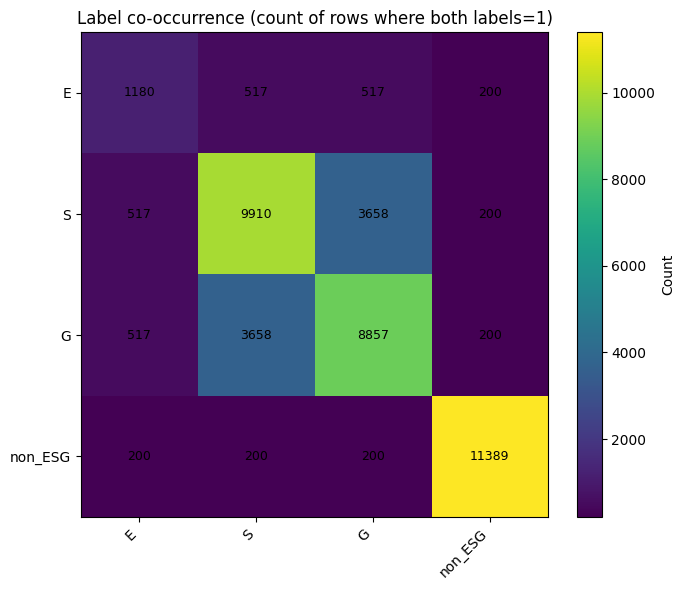

In [7]:

# Label co-occurrence
cooc = pd.DataFrame(index=binary_cols, columns=binary_cols, dtype=int)
for a in binary_cols:
    for b in binary_cols:
        cooc.loc[a, b] = int(((df[a] == 1) & (df[b] == 1)).sum())

display(cooc)

plt.figure(figsize=(7,6))
plt.imshow(cooc.values, aspect='auto')
plt.title('Label co-occurrence (count of rows where both labels=1)')
plt.xticks(range(len(binary_cols)), binary_cols, rotation=45, ha='right')
plt.yticks(range(len(binary_cols)), binary_cols)
for i in range(len(binary_cols)):
    for j in range(len(binary_cols)):
        plt.text(j, i, f'{int(cooc.iloc[i,j])}', ha='center', va='center', fontsize=9)
plt.colorbar(label='Count')
plt.tight_layout()
plt.show()


In [8]:

# Text-derived numeric features
text_series = df[TEXT_COL].fillna('').astype(str)

derived = pd.DataFrame({
    'char_len': text_series.str.len(),
    'word_count': text_series.str.findall(r'\b\w+\b').str.len(),
})
derived['avg_word_len'] = np.where(derived['word_count'] > 0, derived['char_len'] / derived['word_count'], 0).round(2)

tokens = text_series.str.lower().str.findall(r'[a-z]{2,}')
derived['unique_word_ratio'] = tokens.apply(lambda lst: (len(set(lst))/len(lst)) if len(lst) else 0).round(3)
derived['sentence_count'] = text_series.str.count(r'[.!?]+').astype(int)

display(derived.describe().round(2))


,char_len,word_count,avg_word_len,unique_word_ratio,sentence_count
count,26750.00,26750.00,26750.00,26750.00,26750.00
mean,206.73,31.03,6.70,0.86,1.23
std,165.61,24.64,1.17,0.11,1.96
min,0.00,0.00,0.00,0.00,0.00
25%,127.00,19.00,6.20,0.80,1.00
50%,176.00,27.00,6.64,0.88,1.00
75%,241.00,36.00,7.11,0.94,1.00
max,5630.00,839.00,91.00,1.00,130.00


In [9]:

# Outlier analysis (IQR rule)
def iqr_outliers(series):
    s = series.dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    out_mask = (series < low) | (series > high)
    return low, high, int(out_mask.sum()), float(out_mask.mean() * 100)

outlier_rows = []
for c in derived.columns:
    low, high, cnt, pct = iqr_outliers(derived[c])
    outlier_rows.append((c, low, high, cnt, pct, float(derived[c].min()), float(derived[c].max()), float(derived[c].median())))

outlier_df = pd.DataFrame(
    outlier_rows,
    columns=['feature', 'iqr_low', 'iqr_high', 'outlier_count', 'outlier_pct', 'min', 'max', 'median']
).sort_values('outlier_pct', ascending=False).reset_index(drop=True)

display(outlier_df.round(3))


,feature,iqr_low,iqr_high,outlier_count,outlier_pct,min,max,median
0,sentence_count,1.000,1.000,2093,7.824,0.0,130.0,1.000
1,char_len,-44.000,412.000,1335,4.991,0.0,5630.0,176.000
2,word_count,-6.500,61.500,1318,4.927,0.0,839.0,27.000
3,unique_word_ratio,0.593,1.145,507,1.895,0.0,1.0,0.875
4,avg_word_len,4.841,8.471,491,1.836,0.0,91.0,6.640


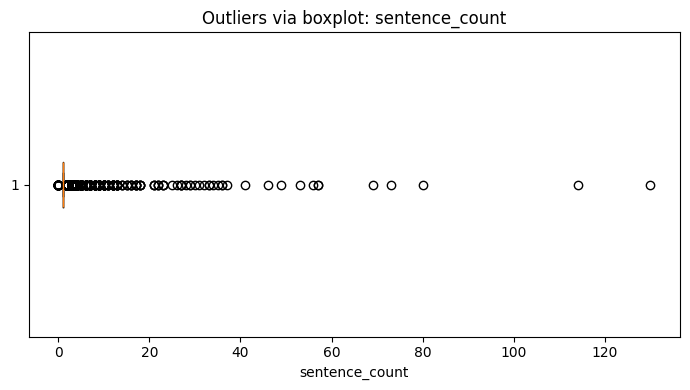

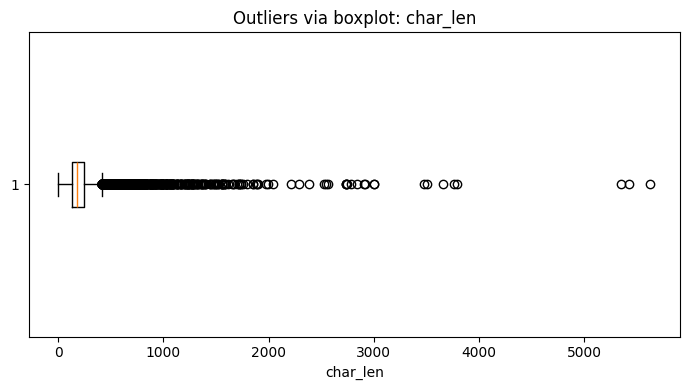

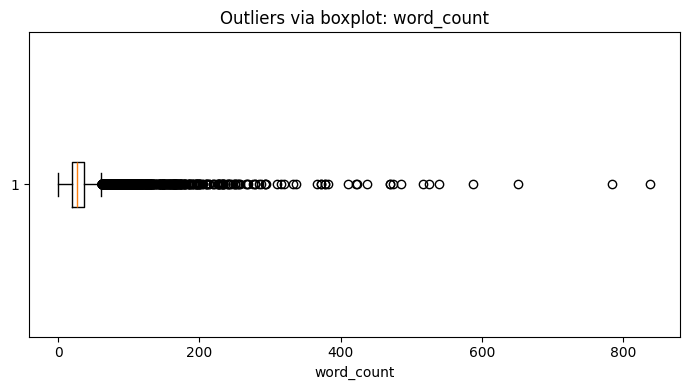

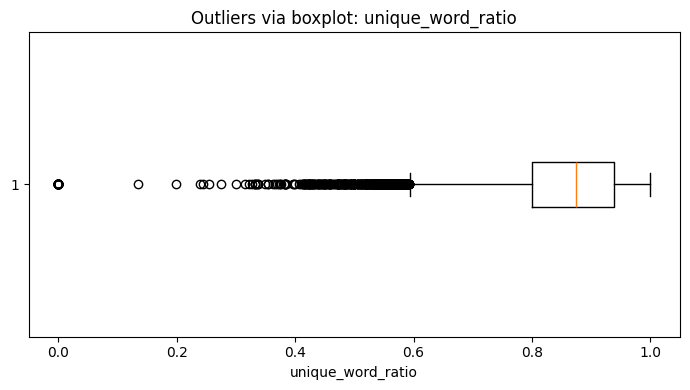

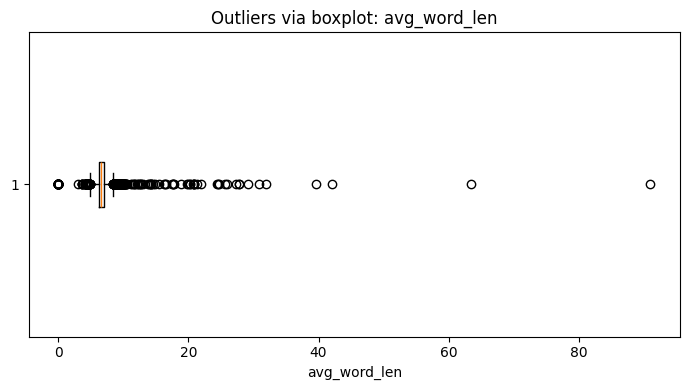

In [10]:

# Boxplots
for feat in outlier_df['feature'].tolist():
    plt.figure(figsize=(7,4))
    plt.boxplot(derived[feat].dropna(), vert=False, showfliers=True)
    plt.title(f'Outliers via boxplot: {feat}')
    plt.xlabel(feat)
    plt.tight_layout()
    plt.show()


In [11]:

# Extreme examples
df_with_derived = df.copy()
for c in derived.columns:
    df_with_derived[c] = derived[c].values

top_long = df_with_derived.sort_values('char_len', ascending=False).head(10)[['id', TEXT_COL] + binary_cols + ['char_len', 'word_count', 'sentence_count']]
display(top_long)


,id,text,E,S,G,non_ESG,char_len,word_count,sentence_count
6512,6512,https://www.fticonsulting.com/emea/-/media/fil...,0,0,0,1,5630,651,114
9868,9868,These forward-looking statements are subject t...,0,0,0,1,5425,839,7
16432,16432,"Among events, risks, uncertainties or factors ...",1,1,1,0,5355,785,1
23419,23419,https://www.sec.gov/Archives/edgar/data/766704...,0,0,0,1,3788,525,130
15721,15721,The space to grow sustainably \tGiving communi...,0,0,0,1,3762,486,1
4432,4432,Each Grantor irrevocably authorizes the Admini...,0,0,0,1,3655,587,2
23573,23573,"Additional risks, uncertainties and other fact...",0,0,0,1,3510,540,6
22308,22308,Certain factors that may affect our future res...,0,0,0,1,3477,517,5
13560,13560,The full extent to which the global COVID-our ...,0,1,1,0,3005,470,9
11600,11600,The full extent to which the global COVID-our ...,0,1,1,0,3005,470,9


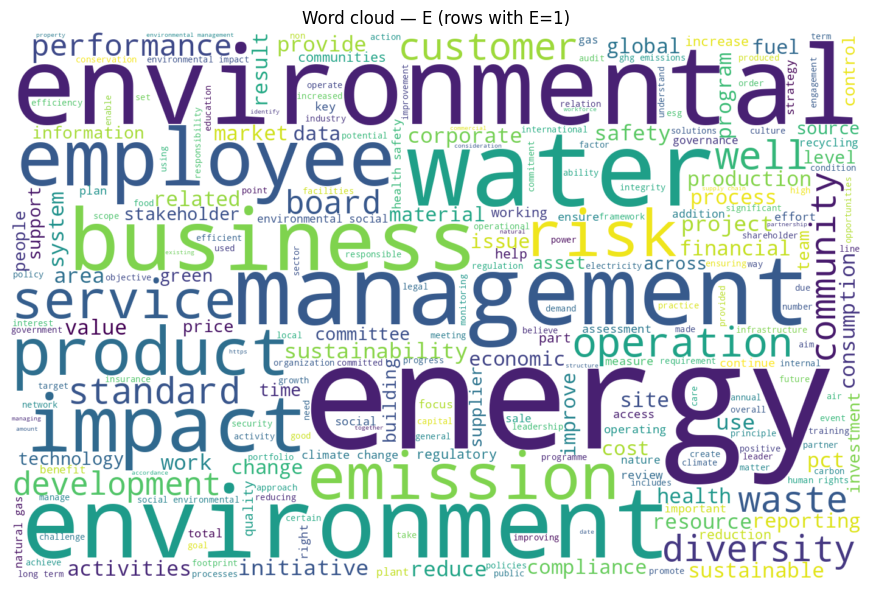

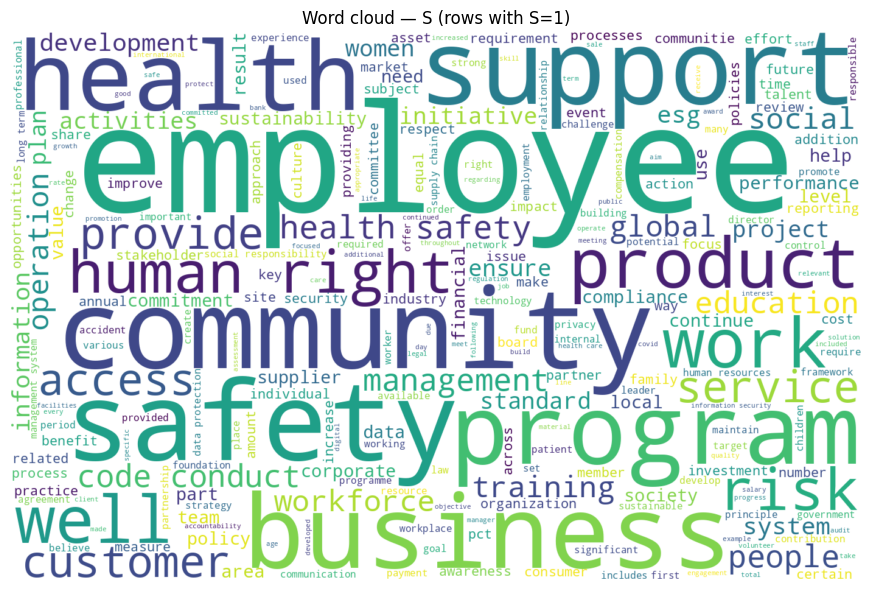

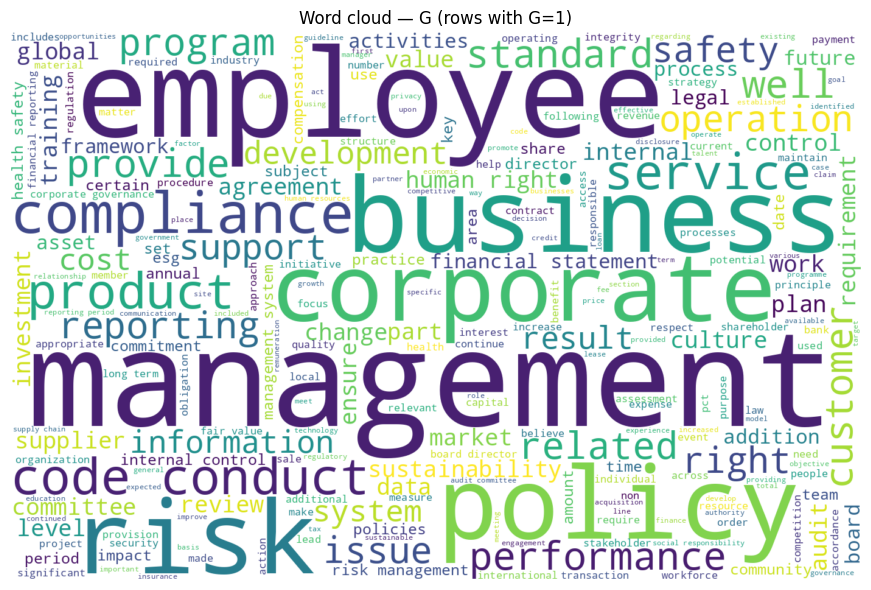

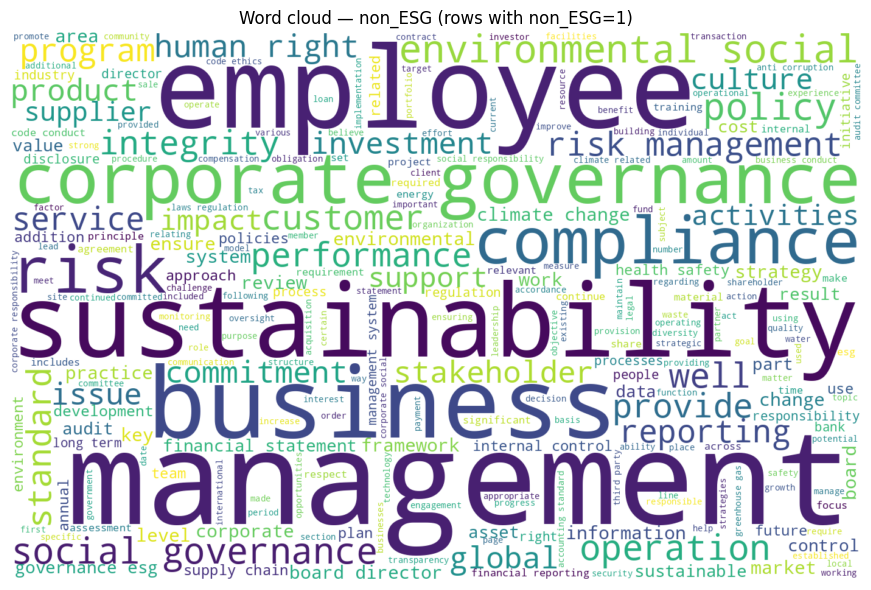

In [12]:

# Word clouds
if not WORDCLOUD_AVAILABLE:
    print('WordCloud is not installed:', WORDCLOUD_IMPORT_ERROR)
else:
    stopwords = set(STOPWORDS)
    stopwords.update({
        'company', 'companies', 'group', 'including', 'include', 'year', 'years',
        'report', 'reports', 'also', 'within', 'may', 'will', 'new', 'one',
        'two', 'three', 'among', 'based'
    })

    def clean_for_wc(texts):
        tokens = texts.str.lower().str.findall(r'[a-z]{3,}')
        all_words = []
        for lst in tokens:
            for w in lst:
                if w not in stopwords:
                    all_words.append(w)
        return ' '.join(all_words)

    for lab in binary_cols:
        subset = df[df[lab] == 1][TEXT_COL].fillna('').astype(str)
        if len(subset) > 12000:
            subset = subset.sample(12000, random_state=42)
        corpus = clean_for_wc(subset)
        if len(corpus) < 50:
            print(f'Skipping {lab}: too little text after cleaning')
            continue

        wc = WordCloud(width=1400, height=900, max_words=250, random_state=42, background_color='white')
        img = wc.generate(corpus)

        plt.figure(figsize=(10,6))
        plt.imshow(img, interpolation='bilinear')
        plt.axis('off')
        plt.title(f'Word cloud — {lab} (rows with {lab}=1)')
        plt.tight_layout()
        plt.show()


In [13]:

# Export summary tables
out_dir = '/mnt/data/eda_notebook_outputs'
os.makedirs(out_dir, exist_ok=True)

label_dist_df.to_csv(os.path.join(out_dir, 'label_distribution.csv'))
outlier_df.to_csv(os.path.join(out_dir, 'outlier_summary_text_features.csv'), index=False)
cooc.to_csv(os.path.join(out_dir, 'label_cooccurrence.csv'))

zip_path = '/mnt/data/eda_notebook_outputs.zip'
with zipfile.ZipFile(zip_path, 'w', compression=zipfile.ZIP_DEFLATED) as z:
    for root, _, files in os.walk(out_dir):
        for f in files:
            full = os.path.join(root, f)
            z.write(full, arcname=os.path.relpath(full, out_dir))

print('Saved outputs to:', out_dir)
print('Saved zip to:', zip_path)


Saved outputs to: /mnt/data/eda_notebook_outputs
Saved zip to: /mnt/data/eda_notebook_outputs.zip
